# Ejercicio 07: Multimodal Embeddings

### realizado por: Correa Adrian
### fecha: 08 de julio de 2026
## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos pertenecen al mismo espacio vectorial (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [14]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Configuración del modelo
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

print("Modelo CLIP y procesador configurados.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Modelo CLIP y procesador configurados.


### 2. Preparar Imágenes de Ejemplo

Dado que hemos tenido problemas persistentes con la carga de imágenes desde URLs externas, generaremos imágenes de marcador de posición (placeholder) directamente en el código para asegurar la ejecución del flujo completo.

In [15]:
# Generaremos imágenes de marcador de posición (224x224 píxeles) con colores sólidos.
images = [
    Image.new('RGB', (224, 224), color = 'red'),    # Imagen de marcador de posición para "gato"
    Image.new('RGB', (224, 224), color = 'green'),  # Imagen de marcador de posición para "elefante"
    Image.new('RGB', (224, 224), color = 'blue')    # Imagen de marcador de posición para "manzana"
]

print("Imágenes de marcador de posición generadas localmente.")

Imágenes de marcador de posición generadas localmente.


### 3. Preparar Textos de Ejemplo

In [16]:
texts = [
    "two cats sleeping on a couch",
    "a group of elephants walking",
    "a green apple on a plate"
]

print("Textos de ejemplo definidos.")

Textos de ejemplo definidos.


### 4. Obtener Embeddings de Imágenes y Textos

Utilizamos el `processor` y el `model` de CLIP para convertir las imágenes y los textos en sus respectivas representaciones vectoriales (embeddings).

In [17]:
inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)

with torch.no_grad():
    outputs = model(**inputs)
    image_embeds = outputs.image_embeds
    text_embeds = outputs.text_embeds

print(f"Dimensión de embeddings de imagen: {image_embeds.shape}")
print(f"Dimensión de embeddings de texto: {text_embeds.shape}")

Dimensión de embeddings de imagen: torch.Size([3, 512])
Dimensión de embeddings de texto: torch.Size([3, 512])


### 5. Normalizar Embeddings

Normalizar los embeddings es una práctica común para asegurar que la similitud del coseno se calcule correctamente.

In [18]:
image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)
text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

print("Embeddings normalizados.")

Embeddings normalizados.


### 6. Visualización con PCA (Reducción de Dimensionalidad)

Para visualizar los embeddings, los reducimos a 2 dimensiones utilizando PCA (Análisis de Componentes Principales) y luego los graficamos.

In [19]:
all_embeds = torch.cat([image_embeds, text_embeds], dim=0).numpy()
pca = PCA(n_components=2)
embeds_2d = pca.fit_transform(all_embeds)

print("Embeddings reducidos a 2D con PCA.")

Embeddings reducidos a 2D con PCA.


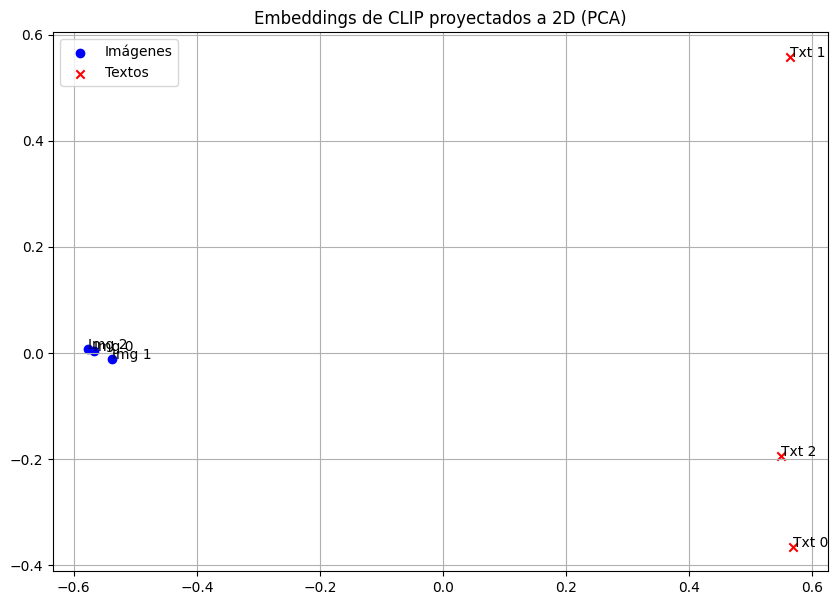

In [20]:
plt.figure(figsize=(10, 7))
n_images = len(images)

# Graficar puntos
plt.scatter(embeds_2d[:n_images, 0], embeds_2d[:n_images, 1], c='blue', label='Imágenes', marker='o')
plt.scatter(embeds_2d[n_images:, 0], embeds_2d[n_images:, 1], c='red', label='Textos', marker='x')

# Anotar puntos
for i, txt in enumerate(texts):
    plt.annotate(f"Img {i}", (embeds_2d[i, 0], embeds_2d[i, 1]))
    plt.annotate(f"Txt {i}", (embeds_2d[n_images+i, 0], embeds_2d[n_images+i, 1]))

plt.legend()
plt.title("Embeddings de CLIP proyectados a 2D (PCA)")
plt.grid(True)
plt.show()

### 7. Verificación de Similitud de Coseno

Calculamos la similitud del coseno entre los embeddings de texto y de imagen para ver cómo se relacionan. Un valor más alto indica mayor similitud.

In [21]:
similarity = cosine_similarity(text_embeds, image_embeds)
print("\nMatriz de Similitud (Texto vs Imagen):")
print(similarity)

# Mostrar emparejamiento automático
print("\nMejor emparejamiento (Texto -> Imagen):")
for i, text in enumerate(texts):
    best_img_idx = np.argmax(similarity[i])
    print(f"Texto: '{text}' -> Mejor Imagen: {best_img_idx} (Score: {similarity[i][best_img_idx]:.4f})")


Matriz de Similitud (Texto vs Imagen):
[[0.1824108  0.19429213 0.18217514]
 [0.17866544 0.19665469 0.17771573]
 [0.19016857 0.2527414  0.18012628]]

Mejor emparejamiento (Texto -> Imagen):
Texto: 'two cats sleeping on a couch' -> Mejor Imagen: 1 (Score: 0.1943)
Texto: 'a group of elephants walking' -> Mejor Imagen: 1 (Score: 0.1967)
Texto: 'a green apple on a plate' -> Mejor Imagen: 1 (Score: 0.2527)
